<img src="./graphics/jazz_and_shap.png"></img>




## Kernel explainer for MLPRegressor (Multi-Layer Perceptron Regressor aka Neural Network)

Neural networks are a class of machine learning models that have been used in the context of supervised, unsupervised and reinforcement learning many years before becoming the foundation for most of the AI applications used today. These are popular models because they are flexible and can be quite powerful when designed and trained properly.

One of the main drawbacks of neural networks is that they are understandably treated as a ***black box*** because the results they generate are not intrinsically explainable.

We'll start exploring how to make the results of a neural network (NN) more explainable by:

1. employing ***permutation importance***
2. using a ***SHAP Kernel Explainer*** and
3. comparing neural network results (implemented with an `MLPRegressor`) with a ***logistic regression model***

We'll train the NN on a heart disease datasets data and use these results to critically assess how different features impact the model's predictions and verify these insights against our existing understanding of the dataset.

## Datasets

### Heart Disease

The first 1025 rows of the kaggle [Heart Disease Prediction Dataset](https://www.kaggle.com/datasets/iamcaano/heart-disease-prediction-dataset?resource=download) [1] were extracted for this analysis.

Column Descriptions:
+ `age` - Age of the patient (years)
+ `sex` - Sex (1 = male, 0 = female)
+ `cp` - Chest pain type (0–3), renamed to `chest_pain_type`
+ `trestbps` - Resting blood pressure (mm Hg), renamed to `resting_blood_pressure`
+ `chol` - Serum cholesterol (mg/dl), **NOT USED**
+ `fbs` - Fasting blood sugar > 120 mg/dl (1 = true, 0 = false), **NOT USED**
+ `restecg` - Resting electrocardiographic results (0–2), renamed to `resting_ecg_results`
+ `thalach` - Maximum heart rate achieved, **NOT USED**
+ `exang` - Exercise-induced angina (1 = yes, 0 = no), **NOT USED**
+ `oldpeak` - ST depression induced by exercise relative to rest, **NOT USED**
+ `slope` - Slope of the peak exercise ST segment (0–2), **NOT USED**
+ `ca` - Number of major vessels (0–3) colored by fluoroscopy, **NOT USED**
+ `thal` - Thalassemia (1 = normal; 2 = fixed defect; 3 = reversible defect), renamed to `thalassemia`
+ `target` - Diagnosis of heart disease (1 = present, 0 = absent)


### Admissions

TODO

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_heart = pd.read_csv('./data/heart.csv')
# take the first 1025 rows
df_heart = df_heart.iloc[:1025]
# take the columns described above
relevant_cols = ['age', 'sex', 'cp', 'trestbps', 'restecg', 'thal', 'target']
df_heart = df_heart.loc[:, relevant_cols]
print(df_heart.shape)
# rename the columns as described above
df_heart = df_heart.rename(columns={'cp': 'chest_pain_type',
                                    'trestbps': 'resting_blood_pressure',
                                    'restecg': 'resting_ecg_results',
                                    'thal': 'thalassemia'})
print(df_heart.columns)
df_heart.head()

(1025, 7)
Index(['age', 'sex', 'chest_pain_type', 'resting_blood_pressure',
       'resting_ecg_results', 'thalassemia', 'target'],
      dtype='str')


,age,sex,chest_pain_type,resting_blood_pressure,resting_ecg_results,thalassemia,target
0,52,1,0,125,1,3,0
1,53,1,0,140,0,3,0
2,70,1,0,145,1,3,0
3,61,1,0,148,1,3,0
4,62,0,0,138,1,2,0


## Permutation importance for MLPClassifier

We'll now use permutation importance to identify which features are most impactful in predicting heart disease with an MLPClassifier. The graphic below describes the basic idea of how ***permutation importance*** works:

<img src="./graphics/permutation_importance.png"></img>

In [3]:
# features
features = ['age', 'sex', 'chest_pain_type', 'resting_blood_pressure',
            'resting_ecg_results', 'thalassemia']
X = df_heart.loc[:, features]
# target
y = df_heart['target']

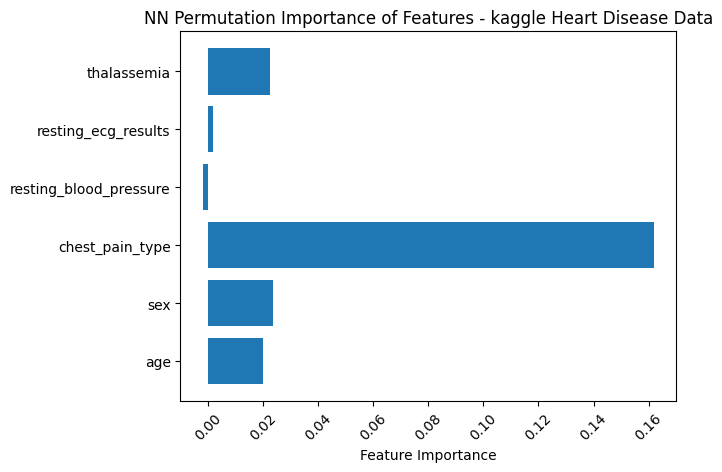

In [4]:
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
# increase max_iter to ensure convergence
model = MLPClassifier(hidden_layer_sizes=(10), max_iter=1000, random_state=1)
model.fit(X, y)

# Compute the permutation importance
result = permutation_importance(model, X, y, n_repeats=10, random_state=1)

# Plot feature importances
fig1, ax1 = plt.subplots()
ax1.barh(X.columns, result.importances_mean)
ax1.set_title("NN Permutation Importance of Features - kaggle Heart Disease Data")
ax1.set_xlabel("Feature Importance")
plt.xticks(rotation=45)
plt.show()

## Coefficients vs. permutation importance

Next, we will compare the patterns identified by permutation importance with the model coefficients from a logistic regression trained on the heart disease dataset. A helper `function plot_importances()` is implemented to plot importances on the same plot.

X containing the features and y containing the labels, and the logistic regression model have been pre-loaded for you. matplotlib.pyplot has been imported as plt.

In [5]:
import numpy as np

def plot_importances(coefficients,  perm_importances):
    features = X.columns  

    x = np.arange(len(features))  # the label locations
    width = 0.35  # the width of the bars

    fig, ax1 = plt.subplots()

    # Plotting coefficients on the primary y-axis
    rects1 = ax1.bar(x - width/2, np.abs(coefficients), width, label='Coefficients', color='b')
    ax1.set_ylabel('Coefficient Magnitude', color='b')
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.set_xticks(x)
    ax1.set_xticklabels(features, rotation=45)
    
    # Creating a secondary y-axis for permutation importances
    ax2 = ax1.twinx()
    rects2 = ax2.bar(x + width/2, perm_importances, width, label='Permutation Importance', color='g')
    ax2.set_ylabel('Permutation Importance', color='g')
    ax2.tick_params(axis='y', labelcolor='g')

    # Adding title and adjusting layout
    ax1.set_title('Logistic Regression Coefficients vs. Permutation Importance')
    fig.tight_layout()

    # Adding legends outside the plot
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    # Placing the legend to the right outside of the plot
    ax1.legend(lines + lines2, labels + labels2, loc='upper left', bbox_to_anchor=(2, 1), borderaxespad=0.)

    # Adjusting the layout to avoid overlap
    plt.subplots_adjust(right=0.8)  # Allows space for the legend on the right

    plt.show()

In [6]:
from sklearn.linear_model import LogisticRegression

# train a logistic regression model
log_reg_model = LogisticRegression()
log_reg_model.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

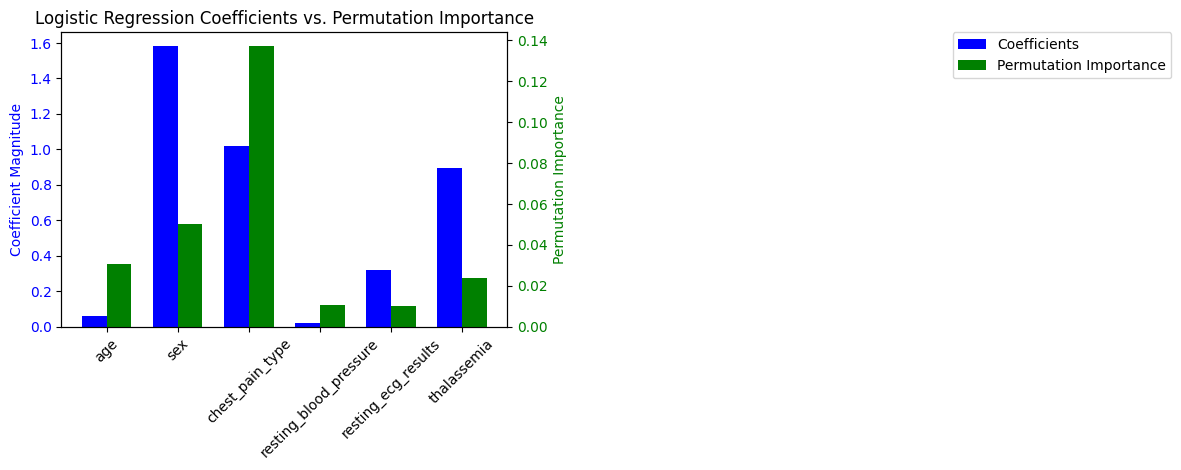

In [7]:
# Extract and store model coefficients
coefficients = log_reg_model.coef_[0]

# Compute permutation importance on the test set
perm_importance = permutation_importance(log_reg_model, X, y, n_repeats=20, random_state=1)

# Compute the average permutation importance
avg_perm_importance = perm_importance.importances_mean

plot_importances(coefficients, avg_perm_importance)

The permuation importance is significantly different from the logistic regression coefficients...

In [8]:
# import seaborn as sns
# import shap
# # read and take init look at the data
# df_ads = pd.read_csv('./data/Admission_Predict_Ver1.1.csv')
# print(df_ads.columns)
# df_ads.info()  # looks like 2 LOR values are missing...
# # df_ads.head()  # first 4 rows identical to kaggle dataset at
#                  # https://www.kaggle.com/datasets/mohansacharya/graduate-admissions
# df_ads.tail()

In [9]:
# from sklearn.model_selection import train_test_split

# features = ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
#             'LOR ', 'CGPA', 'Research', 'Chance of Admit ']

# X_raw = df_ads.loc[:, features]
# y_raw = df_ads.loc[:, ]
# X_train_unscaled = train_test_split()

In [10]:
# # Create a SHAP Kernel Explainer
# explainer = shap.KernelExplainer(
#     model.predict,
#     shap.kmeans(X, 10)
# )

# # Calculate SHAP values
# shap_values = explainer.shap_values(X)

# # Calculate mean absolute SHAP values
# mean_abs_shap = np.abs(shap_values).mean(axis=0)

# plt.bar(X.columns, mean_abs_shap)
# plt.title('Mean Absolute SHAP Values for MLPRegressor')
# plt.xticks(rotation=45)
# plt.show()

## Kernel explainer for MLPClassifier

Neural networks can be very accurate, but understanding their decisions can be challenging due to complexity. Now, we'll leverage the SHAP Kernel Explainer to interpret an `MLPClassifier` trained on the adult income dataset. We will will explore which of the three features: age, education, or hours worked per week is most important for predicting income according to this model.

X containing the predictors and y containing the admission decisions, along with the pre-trained MLPClassifier model, have been pre-loaded for you.

In [11]:
# # Create a SHAP Kernel Explainer
# explainer = shap.KernelExplainer(
#     model.predict_proba,
#     shap.kmeans(X, 10)
# )

# # Calculate SHAP values
# shap_values = explainer.shap_values(X)

# # Calculate mean absolute SHAP values
# mean_abs_shap = np.abs(shap_values[:, :,1]).mean(axis=0)

# plt.bar(X.columns, mean_abs_shap)
# plt.title('Mean Absolute SHAP Values for MLPClassifier')
# plt.xticks(rotation=45)
# plt.show()

## SHAP vs. model-specific approaches

Let's compare the explanatory power of SHAP values from a Kernel Explainer with the logistic regression coefficients, both trained on the income dataset. We'll use the `plot_importances()` function implemented earlier so we can see both importances on the same plot.



In [12]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("mastmustu/income", output_dir='./data/income_data')

# print("Path to dataset files:", path)

In [13]:
# path = kagglehub.dataset_download("uciml/adult-census-income", output_dir='./data/uci_income_data')
# print("Path to dataset files:", path)

# Using LIME for interpretting regressors locally

## Model insurance costs using KNN with the following features:

+ `age`
+ `sex`
+ `BMI`
+ `number of children`
+ `smoking status.`

Original data source: UNKNOWN (downloaded from DataCamp [here](https://assets.datacamp.com/production/repositories/6745/datasets/c50a08e4b83daca7514f47d1baab1dcc67f38ee6/insurance.csv))

In [14]:
# train a KNN model using the entire dataset, because we are accessing how each feature affects predictions
df_ins = pd.read_csv('./data/insurance.csv')
# print(df_ins.shape)
# print(df_ins.columns)
df_ins.info()
df_ins.head()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1335 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   charges   1338 non-null   float64
dtypes: float64(2), int64(4)
memory usage: 62.8 KB


,age,sex,bmi,children,smoker,charges
0,19,0,27.900,0,1,16884.92400
1,18,1,33.770,1,0,1725.55230
2,28,1,33.000,3,0,4449.46200
3,33,1,22.705,0,0,21984.47061
4,32,1,28.880,0,0,3866.85520


In [15]:
from sklearn.neighbors import KNeighborsRegressor as KNNReg

knn_reg = KNNReg()
# drop the rows with missing values
df_no_miss = df_ins[~df_ins['bmi'].isna()]

X = df_no_miss.iloc[:, :-1]
y = df_no_miss.iloc[:, -1]

# https://share.google/aimode/jNHLfUaTEEYDfFc9I
knn_reg.fit(X.values, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


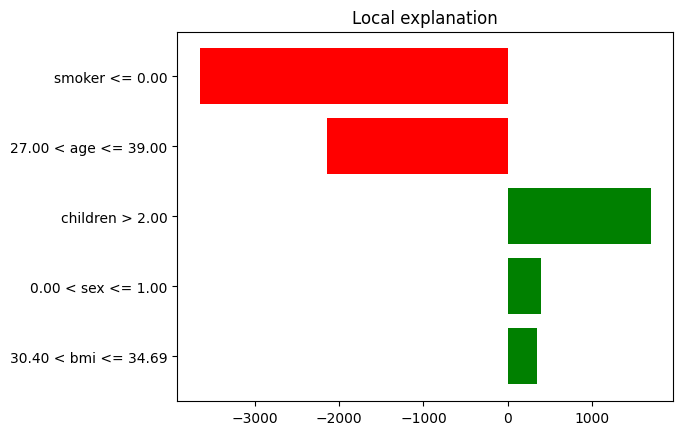

In [16]:
from lime.lime_tabular import LimeTabularExplainer

# https://share.google/aimode/jNHLfUaTEEYDfFc9I
# predict_fn = lambda x: knn_reg.predict(pd.DataFrame(x, columns=X.columns))

sample_data_point = X.iloc[2, :]

# Create the explainer
explainer = LimeTabularExplainer(
    X.values,
    feature_names=X.columns,
    mode='regression'
)

# Generate the explanation
exp = explainer.explain_instance(
    sample_data_point.values,
    knn_reg.predict
)

# Display the explanation
exp.as_pyplot_figure()
plt.show()

## Model heart disease using KNN with the following features:

+ `age`
+ `sex`
+ `chest_pain_type`
+ `resting_blood_pressure`


In [17]:
# use heart data from earlier, but take the above mentioned columns
df_heart_ascp = df_heart.loc[:, ['age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'target']]
df_heart_ascp.info() # no missing values
df_heart_ascp.head()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   age                     1025 non-null   int64
 1   sex                     1025 non-null   int64
 2   chest_pain_type         1025 non-null   int64
 3   resting_blood_pressure  1025 non-null   int64
 4   target                  1025 non-null   int64
dtypes: int64(5)
memory usage: 40.2 KB


,age,sex,chest_pain_type,resting_blood_pressure,target
0,52,1,0,125,0
1,53,1,0,140,0
2,70,1,0,145,0
3,61,1,0,148,0
4,62,0,0,138,0


In [18]:
from sklearn.neighbors import KNeighborsClassifier as KNNClass

X = df_heart_ascp.iloc[:, :-1]
y = df_heart_ascp.iloc[:, -1]

knn_class = KNNClass()
knn_class.fit(X.values, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


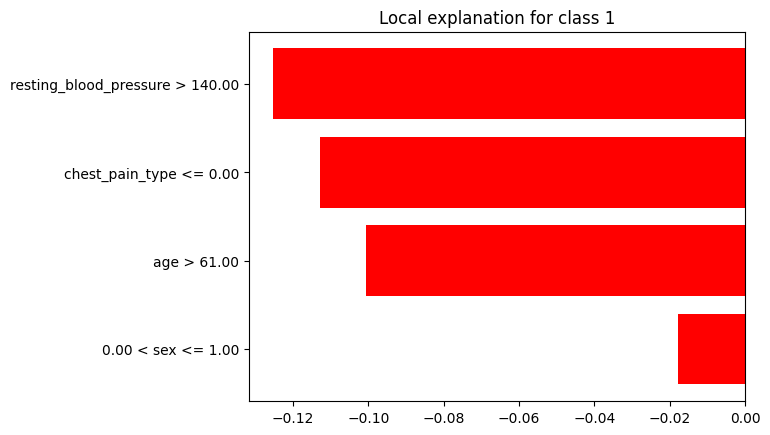

In [19]:
# explain a sample classification prediction
sample_data_point = X.iloc[2, :]

# Create the explainer
explainer = LimeTabularExplainer(
    X.values,
    feature_names=X.columns,
    mode='classification'
)

# Generate the explanation
exp = explainer.explain_instance(
    sample_data_point.values,
    knn_class.predict_proba
)

# Display the explanation
exp.as_pyplot_figure()
plt.show()

# References

1. Heart Disease Data: [https://www.kaggle.com/datasets/iamcaano/heart-disease-prediction-dataset?resource=download](https://www.kaggle.com/datasets/iamcaano/heart-disease-prediction-dataset?resource=download)
2. Admissions Data: [https://www.kaggle.com/datasets/mohansacharya/graduate-admissions/data?select=Admission_Predict_Ver1.1.csv](https://www.kaggle.com/datasets/mohansacharya/graduate-admissions/data?select=Admission_Predict_Ver1.1.csv)